# VQ-VAE Model Evaluation for Calorimeter Hit Reconstruction

This notebook provides comprehensive evaluation of a trained VQ-VAE model including:
1. Reconstruction quality metrics (MSE overall and per-feature)
2. Codebook utilization analysis
3. Latent space visualization (pre/post-quantization)
4. Physics-specific metrics by subdetector (ECAL, HCAL, MUON)

## Imports

In [1]:
%matplotlib inline

from pathlib import Path
import numpy as np
import pandas as pd
import torch
import awkward as ak

### visualization
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt

### dimensionality reduction
from sklearn.decomposition import PCA

### progress tracking
from tqdm.auto import tqdm

### particlemind imports
from particlemind.models.vqvae import VQVAELightning
from particlemind.data.datasets import CLDHits, Collater
from torch.utils.data import DataLoader

### plot settings
%config InlineBackend.figure_format = 'retina'
plt.rcParams['figure.figsize'] = (10, 6)
plt.rc('font', size=12)

/global/cfs/cdirs/m3246/mpettee/hep/particlemind/.venv/lib64/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/global/cfs/cdirs/m3246/mpettee/hep/particlemind/.venv/lib64/python3.11/site-packages/stringcolor/main.py:11: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## Configuration

Modify these paths and parameters for your setup.

In [2]:
### ============ configuration ============

### model checkpoint path - update this to your trained model
CHECKPOINT_PATH = Path("/global/cfs/cdirs/m3246/mpettee/hep/particlemind/outputs/checkpoints/vqvae_training/best_models/")
### list available checkpoints
print("Available checkpoints:")
for ckpt in sorted(CHECKPOINT_PATH.glob("*.ckpt")):
    print(f"  {ckpt.name}")

Available checkpoints:
  embedder_deft-mountain-19_val_loss_epoch=47.ckpt
  embedder_misunderstood-haze-18_val_loss_epoch=47.ckpt
  embedder_test_val_loss_epoch=24.ckpt
  embedder_test_val_loss_epoch=47-v1.ckpt
  embedder_test_val_loss_epoch=47.ckpt


In [3]:
### select your checkpoint - update this
CHECKPOINT_FILE = CHECKPOINT_PATH / "embedder_deft-mountain-19_val_loss_epoch=47.ckpt"  # <-- update this

### data path
DATA_DIR = Path("/global/cfs/cdirs/m3246/mpettee/hep/particlemind/data/processed/p8_ee_tt_ecm365")

### evaluation settings
N_EVAL_FILES = 5  ### number of parquet files to evaluate on
BATCH_SIZE = 16
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

### output directory for plots
OUTPUT_DIR = Path("./plots/evaluation")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

### subdetector configuration (consistent with existing notebooks)
SUBDETECTOR_LABELS = {0: "ECAL", 1: "HCAL", 2: "MUON"}
SUBDETECTOR_COLORS = {0: "steelblue", 1: "green", 2: "orange"}

### feature names
FEATURE_NAMES = ["x (scaled)", "y (scaled)", "z (scaled)", "energy (scaled)"]

print(f"Device: {DEVICE}")
print(f"Checkpoint: {CHECKPOINT_FILE}")
print(f"Data directory: {DATA_DIR}")
print(f"Output directory: {OUTPUT_DIR}")

Device: cuda
Checkpoint: /global/cfs/cdirs/m3246/mpettee/hep/particlemind/outputs/checkpoints/vqvae_training/best_models/embedder_deft-mountain-19_val_loss_epoch=47.ckpt
Data directory: /global/cfs/cdirs/m3246/mpettee/hep/particlemind/data/processed/p8_ee_tt_ecm365
Output directory: plots/evaluation


---
## Load Trained Model

In [4]:
### load the trained vq-vae model from checkpoint
model = VQVAELightning.load_from_checkpoint(CHECKPOINT_FILE, map_location=DEVICE)
model = model.to(DEVICE)
model.eval()

### extract model configuration
print("Model Configuration:")
print(f"  Model type: {model.hparams.get('model_type', 'Unknown')}")
print(f"  Input dim: {model.model.input_dim}")
print(f"  Latent dim: {model.model.latent_dim}")
print(f"  Hidden dim: {model.model.hidden_dim}")

### access vq layer info
num_codes = model.model.vq_kwargs.get("num_codes", 512)
print(f"  Number of codebook entries: {num_codes}")

### access codebook weights
codebook = model.model.vqlayer.codebook.weight.detach().cpu().numpy()
print(f"  Codebook shape: {codebook.shape}")

Model Configuration:
  Model type: VQVAENormFormer
  Input dim: 4
  Latent dim: 16
  Hidden dim: 128
  Number of codebook entries: 512
  Codebook shape: (512, 16)


---
## Load Evaluation Data

In [5]:
### create evaluation dataset
eval_dataset = CLDHits(
    folder_path=DATA_DIR,
    split="val",  ### use validation set for evaluation
    nsamples=N_EVAL_FILES,
    shuffle_files=False
)

### create dataloader with collation
eval_loader = DataLoader(
    eval_dataset,
    batch_size=BATCH_SIZE,
    collate_fn=Collater("all"),
    num_workers=0  ### use 0 for notebook compatibility
)

print(f"Created evaluation dataloader with batch_size={BATCH_SIZE}")

Created evaluation dataloader with batch_size=16


---
## Run Model Inference

Collect model outputs for all evaluation samples.

In [6]:
def run_inference(model, dataloader, device, max_batches=None):
    """
    run inference on the evaluation dataset and collect all outputs.
    
    args:
        model: vqvaelightning model
        dataloader: dataloader for evaluation data
        device: torch device
        max_batches: optional limit on number of batches to process
    
    returns:
        dict: contains original features, reconstructed features, 
              masks, labels, embeddings, and codebook indices
    """
    results = {
        "x_original": [],
        "x_reco": [],
        "masks": [],
        "labels": [],
        "z_pre": [],      ### pre-quantization embeddings
        "z_post": [],     ### post-quantization embeddings
        "code_indices": [],
        "vq_losses": []
    }
    
    model.eval()
    with torch.no_grad():
        for batch_idx, batch in enumerate(tqdm(dataloader, desc="Running inference")):
            if max_batches and batch_idx >= max_batches:
                break
                
            x = batch["calo_hit_features"].to(device)
            mask = batch["calo_hit_mask"].to(device)
            labels = batch["hit_labels"]
            
            ### forward pass through the underlying model
            x_reco, vq_out = model.model(x, mask=mask)
            
            ### store results
            results["x_original"].append(x.cpu().numpy())
            results["x_reco"].append(x_reco.cpu().numpy())
            results["masks"].append(mask.cpu().numpy())
            results["labels"].append(labels.cpu().numpy())
            results["z_pre"].append(vq_out["z"].cpu().numpy())
            results["z_post"].append(vq_out["z_q"].cpu().numpy())
            results["code_indices"].append(vq_out["q"].cpu().numpy())
            results["vq_losses"].append(vq_out["loss"].cpu().item())
    
    return results

In [7]:
### run inference on evaluation data
### limit to 100 batches for faster evaluation (remove max_batches for full evaluation)
results = run_inference(model, eval_loader, DEVICE, max_batches=100)

print("\nInference complete!")
print(f"  Total batches processed: {len(results['x_original'])}")
print(f"  Average VQ loss: {np.mean(results['vq_losses']):.6f}")

Running inference: 100%|██████████| 1/1 [00:00<00:00,  1.24it/s]



Inference complete!
  Total batches processed: 1
  Average VQ loss: 0.205773


---
# 1. Reconstruction Quality Analysis

Evaluate how well the VQ-VAE reconstructs calorimeter hits.

In [8]:
def compute_reconstruction_metrics(results):
    """
    compute per-feature and overall reconstruction metrics.
    
    returns:
        dict: contains mse metrics overall and per feature
    """
    metrics = {
        "overall_mse": [],
        "per_feature_mse": {i: [] for i in range(4)},
        "per_feature_mae": {i: [] for i in range(4)},
    }
    
    for i in range(len(results["x_original"])):
        x_orig = results["x_original"][i]
        x_reco = results["x_reco"][i]
        mask = results["masks"][i]
        
        ### flatten valid hits only
        valid = mask.flatten() == 1
        x_orig_flat = x_orig.reshape(-1, 4)[valid]
        x_reco_flat = x_reco.reshape(-1, 4)[valid]
        
        if len(x_orig_flat) == 0:
            continue
        
        ### overall mse
        mse = np.mean((x_orig_flat - x_reco_flat) ** 2)
        metrics["overall_mse"].append(mse)
        
        ### per-feature mse and mae
        for feat_idx in range(4):
            feat_mse = np.mean((x_orig_flat[:, feat_idx] - x_reco_flat[:, feat_idx]) ** 2)
            feat_mae = np.mean(np.abs(x_orig_flat[:, feat_idx] - x_reco_flat[:, feat_idx]))
            metrics["per_feature_mse"][feat_idx].append(feat_mse)
            metrics["per_feature_mae"][feat_idx].append(feat_mae)
    
    return metrics

metrics = compute_reconstruction_metrics(results)

### print summary statistics
print("=" * 50)
print("RECONSTRUCTION QUALITY METRICS")
print("=" * 50)
print(f"\nOverall MSE: {np.mean(metrics['overall_mse']):.6f} +/- {np.std(metrics['overall_mse']):.6f}")
print("\nPer-Feature MSE (scaled coordinates):")
for i, name in enumerate(FEATURE_NAMES):
    mean_mse = np.mean(metrics['per_feature_mse'][i])
    std_mse = np.std(metrics['per_feature_mse'][i])
    mean_mae = np.mean(metrics['per_feature_mae'][i])
    print(f"  {name}: MSE={mean_mse:.6f} +/- {std_mse:.6f}, MAE={mean_mae:.6f}")

RECONSTRUCTION QUALITY METRICS

Overall MSE: 11.370389 +/- 0.000000

Per-Feature MSE (scaled coordinates):
  x (scaled): MSE=1.864237 +/- 0.000000, MAE=1.214007
  y (scaled): MSE=1.773347 +/- 0.000000, MAE=1.131604
  z (scaled): MSE=2.061296 +/- 0.000000, MAE=1.144915
  energy (scaled): MSE=39.782677 +/- 0.000000, MAE=2.071376


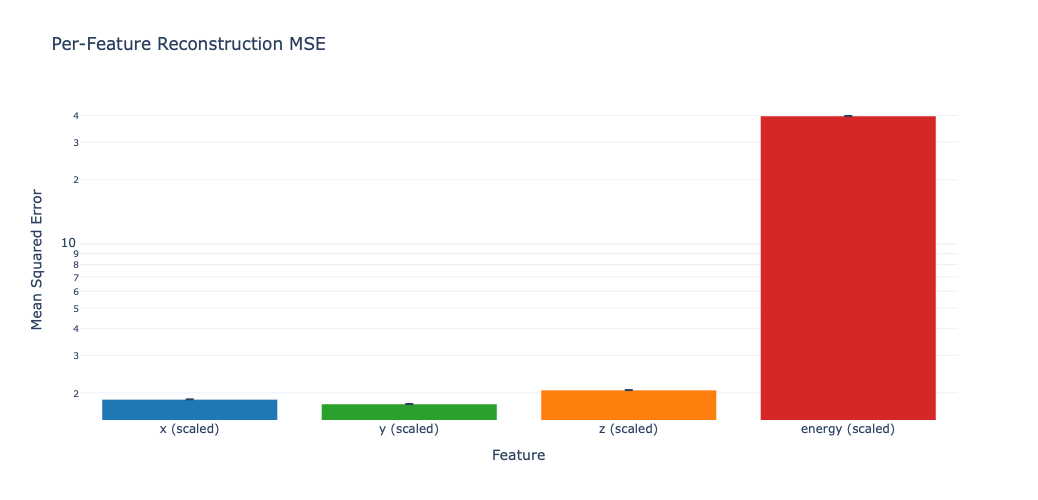

In [9]:
def plot_per_feature_mse(metrics, feature_names):
    """create bar chart of per-feature mse with error bars."""
    means = [np.mean(metrics['per_feature_mse'][i]) for i in range(4)]
    stds = [np.std(metrics['per_feature_mse'][i]) for i in range(4)]
    
    fig = go.Figure()
    fig.add_trace(go.Bar(
        x=feature_names,
        y=means,
        error_y=dict(type='data', array=stds, visible=True),
        marker_color=['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728'],
        name='MSE'
    ))
    
    fig.update_layout(
        title="Per-Feature Reconstruction MSE",
        xaxis_title="Feature",
        yaxis_title="Mean Squared Error",
        yaxis_type="log",
        template="plotly_white",
        width=700,
        height=500
    )
    
    fig.show()
    fig.write_html(OUTPUT_DIR / "per_feature_mse.html")

plot_per_feature_mse(metrics, FEATURE_NAMES)

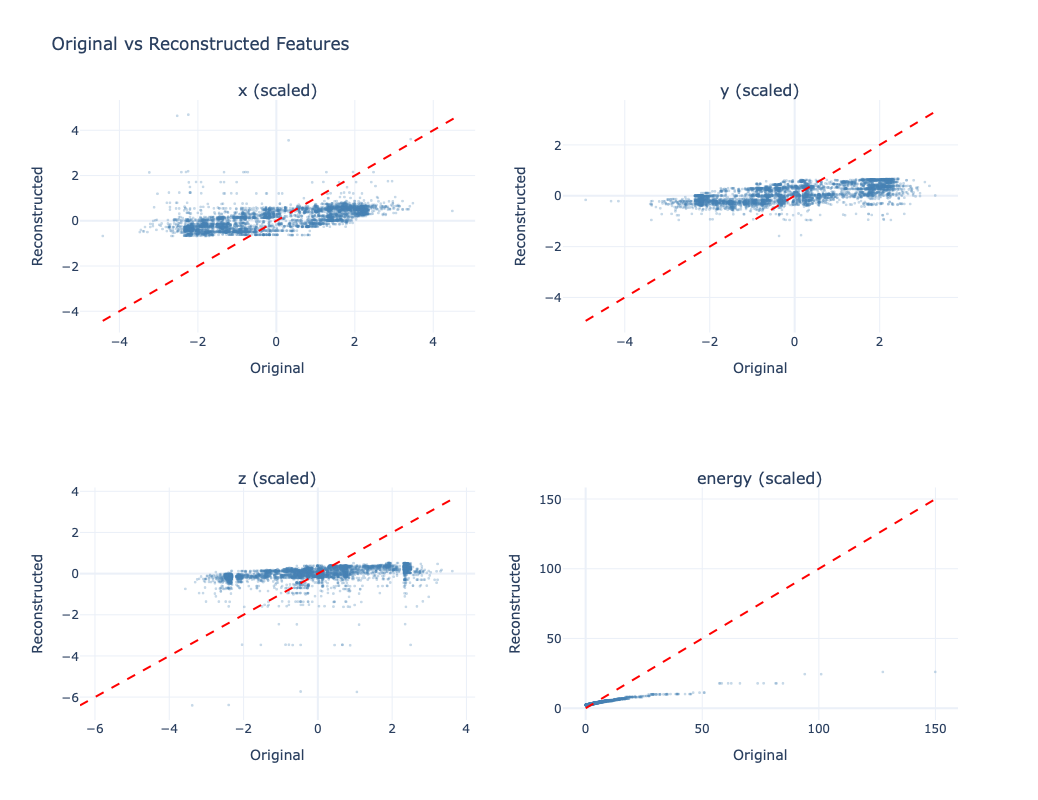

In [10]:
def plot_original_vs_reconstructed(results, n_samples=5000):
    """
    create scatter plots comparing original vs reconstructed values.
    shows diagonal reference line for perfect reconstruction.
    """
    ### collect flattened valid hits
    x_orig_all, x_reco_all = [], []
    
    for i in range(len(results["x_original"])):
        mask = results["masks"][i].flatten() == 1
        x_orig_all.append(results["x_original"][i].reshape(-1, 4)[mask])
        x_reco_all.append(results["x_reco"][i].reshape(-1, 4)[mask])
    
    x_orig = np.vstack(x_orig_all)
    x_reco = np.vstack(x_reco_all)
    
    ### subsample for visualization
    if len(x_orig) > n_samples:
        idx = np.random.choice(len(x_orig), n_samples, replace=False)
        x_orig = x_orig[idx]
        x_reco = x_reco[idx]
    
    fig = make_subplots(rows=2, cols=2, subplot_titles=FEATURE_NAMES)
    
    for i in range(4):
        row, col = (i // 2) + 1, (i % 2) + 1
        
        ### scatter plot
        fig.add_trace(
            go.Scatter(
                x=x_orig[:, i], y=x_reco[:, i],
                mode='markers',
                marker=dict(size=3, opacity=0.3, color='steelblue'),
                name=FEATURE_NAMES[i],
                showlegend=False
            ),
            row=row, col=col
        )
        
        ### add diagonal reference line
        min_val = min(x_orig[:, i].min(), x_reco[:, i].min())
        max_val = max(x_orig[:, i].max(), x_reco[:, i].max())
        fig.add_trace(
            go.Scatter(
                x=[min_val, max_val], y=[min_val, max_val],
                mode='lines',
                line=dict(color='red', dash='dash'),
                showlegend=False
            ),
            row=row, col=col
        )
        
        fig.update_xaxes(title_text="Original", row=row, col=col)
        fig.update_yaxes(title_text="Reconstructed", row=row, col=col)
    
    fig.update_layout(
        title="Original vs Reconstructed Features",
        height=800, width=900,
        template="plotly_white"
    )
    
    fig.show()
    fig.write_html(OUTPUT_DIR / "original_vs_reconstructed.html")

plot_original_vs_reconstructed(results)

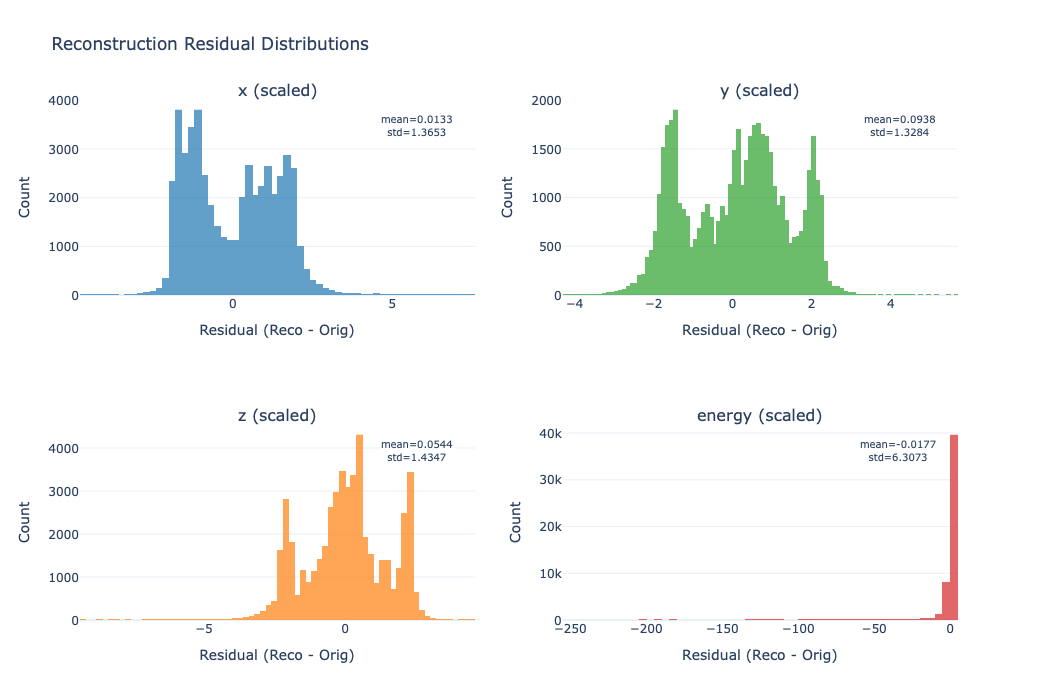

In [11]:
def plot_residual_distributions(results):
    """plot histograms of reconstruction residuals for each feature."""
    residuals = {i: [] for i in range(4)}
    
    for i in range(len(results["x_original"])):
        mask = results["masks"][i].flatten() == 1
        x_orig = results["x_original"][i].reshape(-1, 4)[mask]
        x_reco = results["x_reco"][i].reshape(-1, 4)[mask]
        
        for feat in range(4):
            residuals[feat].extend(x_reco[:, feat] - x_orig[:, feat])
    
    fig = make_subplots(rows=2, cols=2, subplot_titles=FEATURE_NAMES)
    colors = ['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728']
    
    for i in range(4):
        row, col = (i // 2) + 1, (i % 2) + 1
        res = np.array(residuals[i])
        
        fig.add_trace(
            go.Histogram(
                x=res,
                nbinsx=100,
                marker_color=colors[i],
                opacity=0.7,
                name=FEATURE_NAMES[i]
            ),
            row=row, col=col
        )
        
        ### add statistics annotation
        mean_res = np.mean(res)
        std_res = np.std(res)
        fig.add_annotation(
            text=f"mean={mean_res:.4f}<br>std={std_res:.4f}",
            xref=f"x{i+1 if i > 0 else ''} domain",
            yref=f"y{i+1 if i > 0 else ''} domain",
            x=0.95, y=0.95,
            showarrow=False,
            font=dict(size=10),
            bgcolor="white"
        )
        
        fig.update_xaxes(title_text="Residual (Reco - Orig)", row=row, col=col)
        fig.update_yaxes(title_text="Count", row=row, col=col)
    
    fig.update_layout(
        title="Reconstruction Residual Distributions",
        height=700, width=900,
        showlegend=False,
        template="plotly_white"
    )
    
    fig.show()
    fig.write_html(OUTPUT_DIR / "residual_distributions.html")

plot_residual_distributions(results)

---
# 2. Codebook Utilization Analysis

Analyze how effectively the VQ-VAE uses its codebook entries.

In [12]:
def compute_codebook_stats(results, num_codes):
    """
    compute codebook utilization statistics.
    
    returns:
        dict: contains token counts, usage percentage, dead codes
    """
    all_codes = []
    
    for i in range(len(results["code_indices"])):
        codes = results["code_indices"][i]
        mask = results["masks"][i]
        ### only count valid (non-padded) positions
        valid_codes = codes[mask == 1].flatten()
        all_codes.extend(valid_codes)
    
    all_codes = np.array(all_codes)
    
    ### count frequency of each code
    code_counts = np.bincount(all_codes.astype(int), minlength=num_codes)
    
    ### compute statistics
    used_codes = np.sum(code_counts > 0)
    dead_codes = num_codes - used_codes
    usage_percentage = 100 * used_codes / num_codes
    
    ### entropy of code distribution
    probs = code_counts / code_counts.sum()
    probs = probs[probs > 0]  ### avoid log(0)
    entropy = -np.sum(probs * np.log2(probs))
    max_entropy = np.log2(num_codes)
    normalized_entropy = entropy / max_entropy
    
    return {
        "code_counts": code_counts,
        "used_codes": used_codes,
        "dead_codes": dead_codes,
        "usage_percentage": usage_percentage,
        "entropy": entropy,
        "normalized_entropy": normalized_entropy,
        "total_tokens": len(all_codes)
    }

codebook_stats = compute_codebook_stats(results, num_codes)

print("=" * 50)
print("CODEBOOK UTILIZATION STATISTICS")
print("=" * 50)
print(f"Total codebook entries: {num_codes}")
print(f"Used codes: {codebook_stats['used_codes']} ({codebook_stats['usage_percentage']:.1f}%)")
print(f"Dead codes (never used): {codebook_stats['dead_codes']}")
print(f"Total tokens processed: {codebook_stats['total_tokens']:,}")
print(f"Entropy: {codebook_stats['entropy']:.2f} bits (normalized: {codebook_stats['normalized_entropy']:.3f})")

CODEBOOK UTILIZATION STATISTICS
Total codebook entries: 512
Used codes: 463 (90.4%)
Dead codes (never used): 49
Total tokens processed: 50,111
Entropy: 7.64 bits (normalized: 0.849)


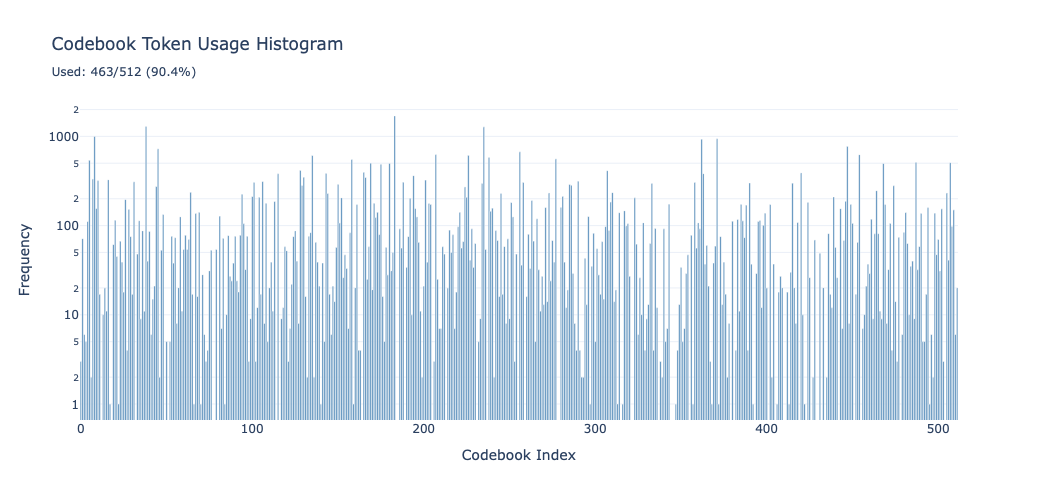

In [13]:
def plot_token_frequency_histogram(codebook_stats, num_codes):
    """create histogram of token/code usage frequencies."""
    code_counts = codebook_stats["code_counts"]
    
    fig = go.Figure()
    
    ### bar chart of code frequencies
    fig.add_trace(go.Bar(
        x=np.arange(num_codes),
        y=code_counts,
        marker_color='steelblue',
        name='Frequency'
    ))
    
    fig.update_layout(
        title=f"Codebook Token Usage Histogram<br><sub>Used: {codebook_stats['used_codes']}/{num_codes} ({codebook_stats['usage_percentage']:.1f}%)</sub>",
        xaxis_title="Codebook Index",
        yaxis_title="Frequency",
        yaxis_type="log",
        template="plotly_white",
        width=1000,
        height=500
    )
    
    fig.show()
    fig.write_html(OUTPUT_DIR / "codebook_frequency_histogram.html")

plot_token_frequency_histogram(codebook_stats, num_codes)

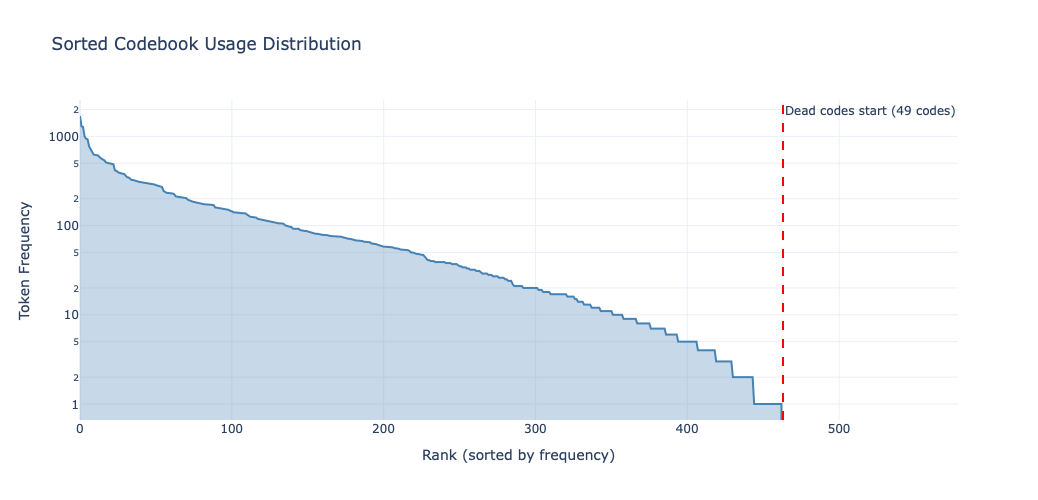

In [14]:
def plot_sorted_frequency(codebook_stats):
    """plot sorted code frequencies to visualize distribution."""
    sorted_counts = np.sort(codebook_stats["code_counts"])[::-1]
    
    fig = go.Figure()
    
    fig.add_trace(go.Scatter(
        x=np.arange(len(sorted_counts)),
        y=sorted_counts,
        mode='lines',
        fill='tozeroy',
        fillcolor='rgba(70, 130, 180, 0.3)',
        line=dict(color='steelblue', width=2),
        name='Frequency'
    ))
    
    ### mark dead codes threshold
    dead_start = codebook_stats["used_codes"]
    fig.add_vline(
        x=dead_start,
        line_dash="dash",
        line_color="red",
        annotation_text=f"Dead codes start ({codebook_stats['dead_codes']} codes)"
    )
    
    fig.update_layout(
        title="Sorted Codebook Usage Distribution",
        xaxis_title="Rank (sorted by frequency)",
        yaxis_title="Token Frequency",
        yaxis_type="log",
        template="plotly_white",
        width=900,
        height=500
    )
    
    fig.show()
    fig.write_html(OUTPUT_DIR / "codebook_sorted_frequency.html")

plot_sorted_frequency(codebook_stats)

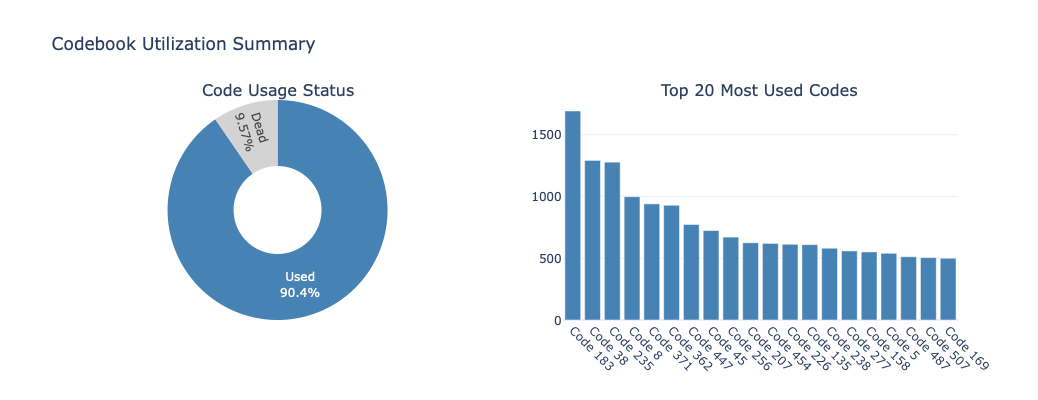

In [15]:
def plot_codebook_summary(codebook_stats, num_codes):
    """create summary pie chart of codebook utilization."""
    fig = make_subplots(
        rows=1, cols=2,
        specs=[[{"type": "pie"}, {"type": "bar"}]],
        subplot_titles=["Code Usage Status", "Top 20 Most Used Codes"]
    )
    
    ### pie chart: used vs dead
    fig.add_trace(
        go.Pie(
            labels=["Used", "Dead"],
            values=[codebook_stats["used_codes"], codebook_stats["dead_codes"]],
            marker_colors=["steelblue", "lightgray"],
            hole=0.4,
            textinfo='label+percent'
        ),
        row=1, col=1
    )
    
    ### bar chart: top 20 codes
    sorted_indices = np.argsort(codebook_stats["code_counts"])[::-1][:20]
    top_counts = codebook_stats["code_counts"][sorted_indices]
    
    fig.add_trace(
        go.Bar(
            x=[f"Code {i}" for i in sorted_indices],
            y=top_counts,
            marker_color='steelblue'
        ),
        row=1, col=2
    )
    
    fig.update_layout(
        title="Codebook Utilization Summary",
        template="plotly_white",
        height=400,
        width=1000,
        showlegend=False
    )
    
    fig.update_xaxes(tickangle=45, row=1, col=2)
    
    fig.show()
    fig.write_html(OUTPUT_DIR / "codebook_summary.html")

plot_codebook_summary(codebook_stats, num_codes)

---
# 3. Latent Space Analysis

Visualize pre-quantization and post-quantization embeddings.

In [16]:
def collect_embeddings(results, max_samples=10000):
    """
    collect and flatten embeddings for visualization.
    
    returns:
        dict: contains z_pre, z_post arrays and associated metadata
    """
    z_pre_list, z_post_list = [], []
    code_idx_list = []
    
    total_collected = 0
    
    ### get latent dimension from first batch
    latent_dim = results["z_pre"][0].shape[-1]
    
    for i in range(len(results["z_pre"])):
        mask = results["masks"][i]
        z_pre_batch = results["z_pre"][i]
        z_post_batch = results["z_post"][i]
        codes_batch = results["code_indices"][i]
        
        ### process each sample in batch
        for j in range(mask.shape[0]):
            valid = mask[j] == 1
            n_valid = int(valid.sum())
            
            if n_valid == 0:
                continue
            
            if total_collected + n_valid > max_samples:
                n_take = max_samples - total_collected
                valid_indices = np.where(valid)[0][:n_take]
            else:
                valid_indices = np.where(valid)[0]
            
            ### extract embeddings and ensure 2d shape (n_samples, latent_dim)
            z_pre = z_pre_batch[j, valid_indices].reshape(-1, latent_dim)
            z_post = z_post_batch[j, valid_indices].reshape(-1, latent_dim)
            codes = codes_batch[j, valid_indices].flatten()
            
            z_pre_list.append(z_pre)
            z_post_list.append(z_post)
            code_idx_list.append(codes)
            
            total_collected += len(valid_indices)
            if total_collected >= max_samples:
                break
        
        if total_collected >= max_samples:
            break
    
    return {
        "z_pre": np.vstack(z_pre_list) if z_pre_list else np.array([]),
        "z_post": np.vstack(z_post_list) if z_post_list else np.array([]),
        "code_indices": np.concatenate(code_idx_list) if code_idx_list else np.array([])
    }

embeddings = collect_embeddings(results, max_samples=10000)
print(f"Collected {len(embeddings['z_pre'])} embedding samples")
print(f"Embedding dimension: {embeddings['z_pre'].shape[1] if len(embeddings['z_pre']) > 0 else 'N/A'}")

Collected 10000 embedding samples
Embedding dimension: 16


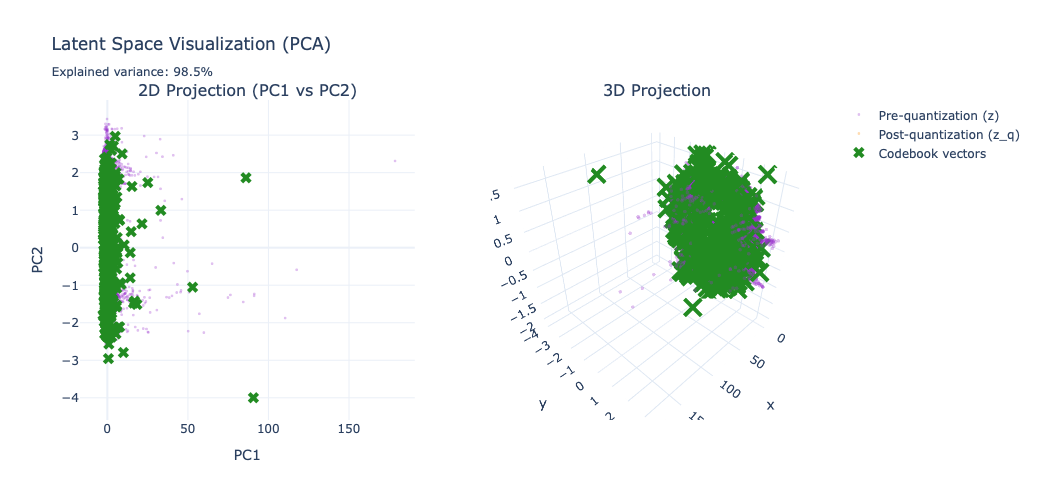

In [17]:
def plot_latent_space_pca(embeddings, codebook):
    """
    visualize latent space using pca projection.
    shows pre-quantization, post-quantization, and codebook vectors.
    """
    if len(embeddings["z_pre"]) == 0:
        print("No embeddings collected, skipping visualization")
        return None
    
    ### fit pca on combined data
    combined = np.vstack([embeddings["z_pre"], embeddings["z_post"], codebook])
    pca = PCA(n_components=3)
    combined_pca = pca.fit_transform(combined)
    
    n_samples = len(embeddings["z_pre"])
    z_pre_pca = combined_pca[:n_samples]
    z_post_pca = combined_pca[n_samples:2*n_samples]
    codebook_pca = combined_pca[2*n_samples:]
    
    ### subsample for visualization
    n_plot = min(5000, n_samples)
    indices = np.random.choice(n_samples, n_plot, replace=False)
    
    fig = make_subplots(
        rows=1, cols=2,
        subplot_titles=["2D Projection (PC1 vs PC2)", "3D Projection"],
        specs=[[{"type": "scatter"}, {"type": "scatter3d"}]]
    )
    
    ### 2d plot
    fig.add_trace(
        go.Scatter(
            x=z_pre_pca[indices, 0], y=z_pre_pca[indices, 1],
            mode='markers',
            marker=dict(size=3, color='darkorchid', opacity=0.3),
            name='Pre-quantization (z)'
        ),
        row=1, col=1
    )
    
    fig.add_trace(
        go.Scatter(
            x=z_post_pca[indices, 0], y=z_post_pca[indices, 1],
            mode='markers',
            marker=dict(size=3, color='darkorange', opacity=0.3),
            name='Post-quantization (z_q)'
        ),
        row=1, col=1
    )
    
    fig.add_trace(
        go.Scatter(
            x=codebook_pca[:, 0], y=codebook_pca[:, 1],
            mode='markers',
            marker=dict(size=10, color='forestgreen', symbol='x'),
            name='Codebook vectors'
        ),
        row=1, col=1
    )
    
    ### 3d plot
    fig.add_trace(
        go.Scatter3d(
            x=z_pre_pca[indices, 0], y=z_pre_pca[indices, 1], z=z_pre_pca[indices, 2],
            mode='markers',
            marker=dict(size=2, color='darkorchid', opacity=0.3),
            name='Pre-quantization',
            showlegend=False
        ),
        row=1, col=2
    )
    
    fig.add_trace(
        go.Scatter3d(
            x=codebook_pca[:, 0], y=codebook_pca[:, 1], z=codebook_pca[:, 2],
            mode='markers',
            marker=dict(size=5, color='forestgreen', symbol='x'),
            name='Codebook',
            showlegend=False
        ),
        row=1, col=2
    )
    
    fig.update_layout(
        title=f"Latent Space Visualization (PCA)<br><sub>Explained variance: {100*sum(pca.explained_variance_ratio_[:3]):.1f}%</sub>",
        height=500,
        width=1200,
        template="plotly_white"
    )
    
    fig.update_xaxes(title_text="PC1", row=1, col=1)
    fig.update_yaxes(title_text="PC2", row=1, col=1)
    
    fig.show()
    fig.write_html(OUTPUT_DIR / "latent_space_pca.html")
    
    return pca

pca = plot_latent_space_pca(embeddings, codebook)

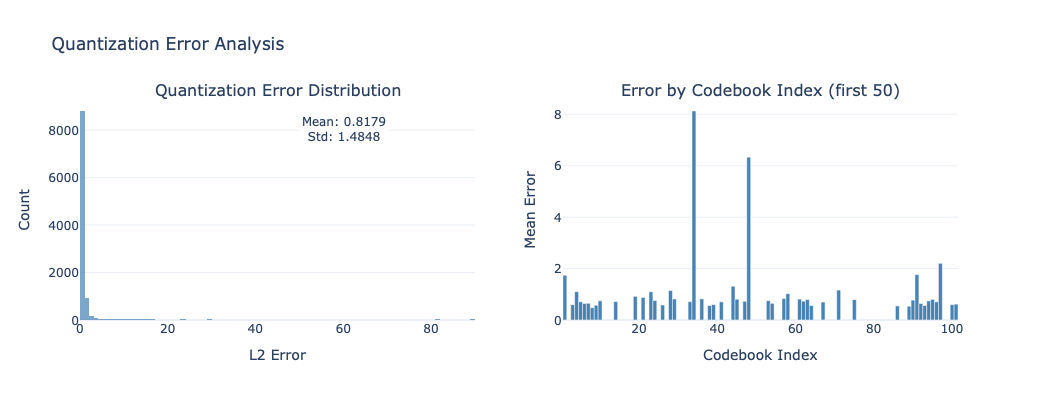

In [18]:
def plot_quantization_error(embeddings):
    """
    visualize the quantization error (distance from z to z_q).
    """
    if len(embeddings["z_pre"]) == 0:
        print("No embeddings collected, skipping visualization")
        return
    
    ### compute l2 distance between pre and post quantization
    quant_errors = np.linalg.norm(embeddings["z_pre"] - embeddings["z_post"], axis=1)
    
    fig = make_subplots(
        rows=1, cols=2,
        subplot_titles=["Quantization Error Distribution", "Error by Codebook Index (first 50)"]
    )
    
    ### histogram of quantization errors
    fig.add_trace(
        go.Histogram(
            x=quant_errors,
            nbinsx=100,
            marker_color='steelblue',
            opacity=0.7,
            name='Quantization Error'
        ),
        row=1, col=1
    )
    
    ### mean error per codebook index
    unique_codes = np.unique(embeddings["code_indices"].astype(int))
    mean_errors = []
    for code in unique_codes[:50]:  ### limit to first 50 for display
        mask = embeddings["code_indices"] == code
        if mask.sum() > 0:
            mean_errors.append(quant_errors[mask].mean())
        else:
            mean_errors.append(0)
    
    fig.add_trace(
        go.Bar(
            x=unique_codes[:50],
            y=mean_errors,
            marker_color='steelblue',
            name='Mean Error by Code'
        ),
        row=1, col=2
    )
    
    fig.add_annotation(
        x=0.25, y=0.95,
        xref="paper", yref="paper",
        text=f"Mean: {quant_errors.mean():.4f}<br>Std: {quant_errors.std():.4f}",
        showarrow=False,
        font=dict(size=12),
        bgcolor="white"
    )
    
    fig.update_layout(
        title="Quantization Error Analysis",
        height=400,
        width=1100,
        template="plotly_white",
        showlegend=False
    )
    
    fig.update_xaxes(title_text="L2 Error", row=1, col=1)
    fig.update_yaxes(title_text="Count", row=1, col=1)
    fig.update_xaxes(title_text="Codebook Index", row=1, col=2)
    fig.update_yaxes(title_text="Mean Error", row=1, col=2)
    
    fig.show()
    fig.write_html(OUTPUT_DIR / "quantization_error.html")

plot_quantization_error(embeddings)

---
# 4. Physics-Specific Metrics

Analyze reconstruction performance by subdetector and physical quantities.

In [19]:
def extract_with_subdetector_info(results):
    """
    collect data and approximate subdetector based on radial position.
    
    note: this is an approximation based on typical cld detector geometry:
    - ecal: inner radii (r < 2.0m scaled = 2.0)
    - hcal: middle radii (2.0 <= r < 4.0)
    - muon: outer radii (r >= 4.0)
    """
    x_orig_all, x_reco_all = [], []
    
    for i in range(len(results["x_original"])):
        mask = results["masks"][i].flatten() == 1
        x_orig = results["x_original"][i].reshape(-1, 4)[mask]
        x_reco = results["x_reco"][i].reshape(-1, 4)[mask]
        x_orig_all.append(x_orig)
        x_reco_all.append(x_reco)
    
    x_orig = np.vstack(x_orig_all)
    x_reco = np.vstack(x_reco_all)
    
    ### compute radial distance in scaled coordinates
    r = np.sqrt(x_orig[:, 0]**2 + x_orig[:, 1]**2)
    
    ### approximate subdetector assignment based on radial position
    subdetector = np.zeros(len(r), dtype=int)
    subdetector[(r >= 2.0)] = 1  ### hcal
    subdetector[(r >= 4.0)] = 2  ### muon
    
    return x_orig, x_reco, subdetector

x_orig, x_reco, subdetector = extract_with_subdetector_info(results)

print(f"Total hits: {len(x_orig)}")
for sd_code, sd_name in SUBDETECTOR_LABELS.items():
    n_hits = (subdetector == sd_code).sum()
    print(f"  {sd_name}: {n_hits} hits ({100*n_hits/len(x_orig):.1f}%)")

Total hits: 50111
  ECAL: 10250 hits (20.5%)
  HCAL: 39821 hits (79.5%)
  MUON: 40 hits (0.1%)


In [20]:
def compute_per_subdetector_metrics(x_orig, x_reco, subdetector):
    """compute reconstruction metrics broken down by subdetector."""
    metrics = {}
    
    for sd_code, sd_name in SUBDETECTOR_LABELS.items():
        mask = subdetector == sd_code
        if mask.sum() == 0:
            continue
            
        x_o = x_orig[mask]
        x_r = x_reco[mask]
        
        metrics[sd_name] = {
            "n_hits": int(mask.sum()),
            "overall_mse": float(np.mean((x_o - x_r) ** 2)),
            "per_feature_mse": [float(np.mean((x_o[:, i] - x_r[:, i]) ** 2)) for i in range(4)],
            "per_feature_mae": [float(np.mean(np.abs(x_o[:, i] - x_r[:, i]))) for i in range(4)],
        }
    
    return metrics

subdet_metrics = compute_per_subdetector_metrics(x_orig, x_reco, subdetector)

print("=" * 60)
print("PER-SUBDETECTOR RECONSTRUCTION METRICS")
print("=" * 60)
for sd_name, m in subdet_metrics.items():
    print(f"\n{sd_name} ({m['n_hits']:,} hits):")
    print(f"  Overall MSE: {m['overall_mse']:.6f}")
    for i, feat in enumerate(FEATURE_NAMES):
        print(f"  {feat}: MSE={m['per_feature_mse'][i]:.6f}, MAE={m['per_feature_mae'][i]:.6f}")

PER-SUBDETECTOR RECONSTRUCTION METRICS

ECAL (10,250 hits):
  Overall MSE: 8.124291
  x (scaled): MSE=1.457219, MAE=1.090773
  y (scaled): MSE=0.497465, MAE=0.572005
  z (scaled): MSE=5.086470, MAE=2.231577
  energy (scaled): MSE=25.456009, MAE=1.966989

HCAL (39,821 hits):
  Overall MSE: 12.209160
  x (scaled): MSE=1.961251, MAE=1.244189
  y (scaled): MSE=2.091685, MAE=1.273807
  z (scaled): MSE=1.279533, MAE=0.864590
  energy (scaled): MSE=43.504166, MAE=2.097841

MUON (40 hits):
  Overall MSE: 8.165545
  x (scaled): MSE=9.582677, MAE=2.745919
  y (scaled): MSE=11.804042, MAE=2.962322
  z (scaled): MSE=5.125241, MAE=1.758197
  energy (scaled): MSE=6.150224, MAE=2.473666


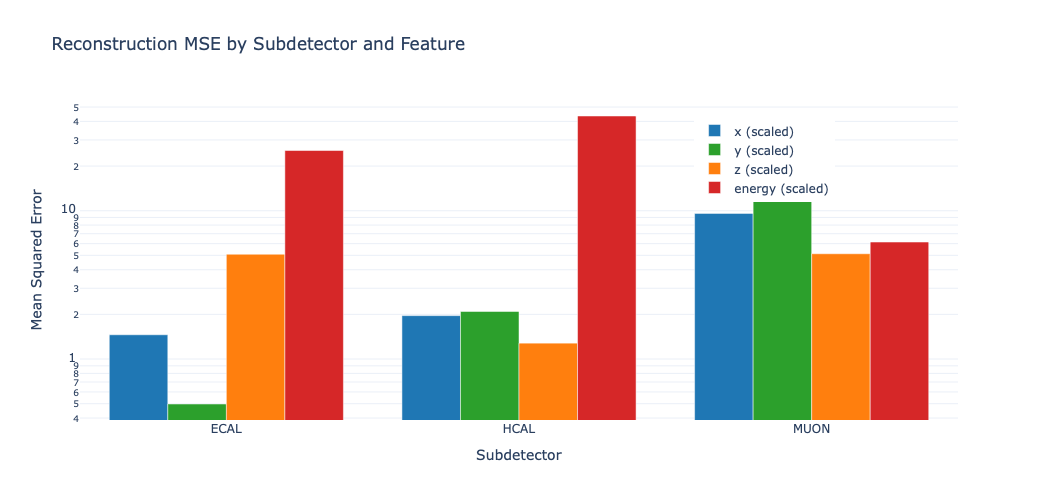

In [21]:
def plot_per_subdetector_mse(subdet_metrics):
    """create grouped bar chart of mse by subdetector and feature."""
    subdetectors = list(subdet_metrics.keys())
    
    if not subdetectors:
        print("No subdetector metrics available")
        return
    
    fig = go.Figure()
    colors = ['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728']
    
    for i, feat in enumerate(FEATURE_NAMES):
        mse_values = [subdet_metrics[sd]["per_feature_mse"][i] for sd in subdetectors]
        
        fig.add_trace(go.Bar(
            x=subdetectors,
            y=mse_values,
            name=feat,
            marker_color=colors[i]
        ))
    
    fig.update_layout(
        title="Reconstruction MSE by Subdetector and Feature",
        xaxis_title="Subdetector",
        yaxis_title="Mean Squared Error",
        yaxis_type="log",
        barmode='group',
        template="plotly_white",
        width=800,
        height=500,
        legend=dict(x=0.7, y=0.95)
    )
    
    fig.show()
    fig.write_html(OUTPUT_DIR / "per_subdetector_mse.html")

plot_per_subdetector_mse(subdet_metrics)

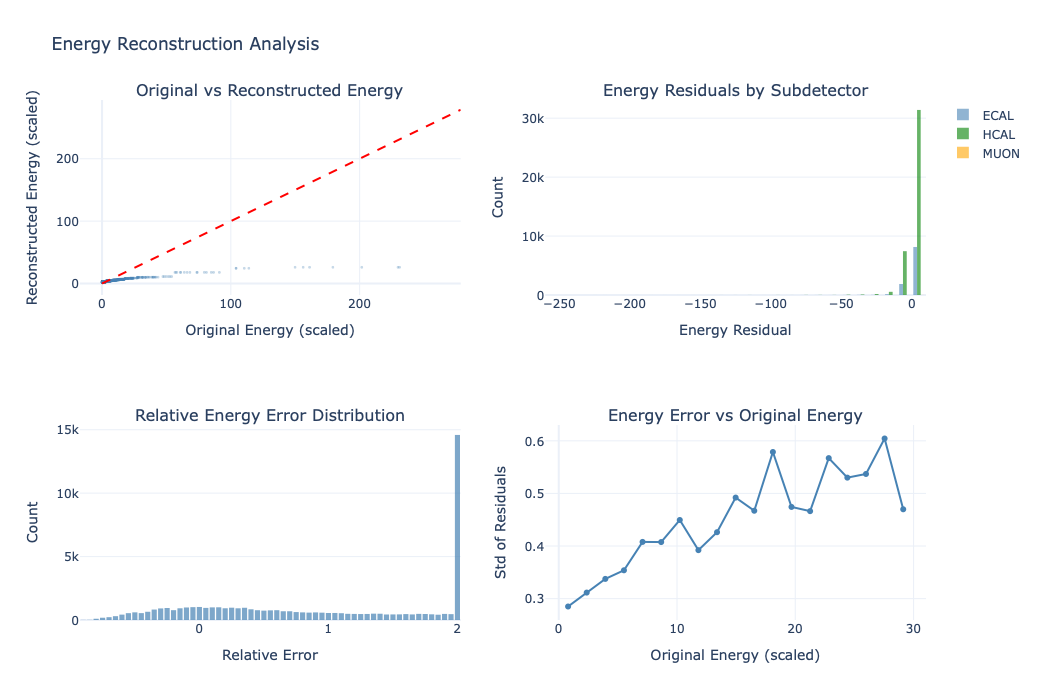

In [22]:
def plot_energy_reconstruction(x_orig, x_reco, subdetector):
    """analyze energy reconstruction quality specifically."""
    energy_orig = x_orig[:, 3]  ### energy is 4th feature
    energy_reco = x_reco[:, 3]
    
    fig = make_subplots(
        rows=2, cols=2,
        subplot_titles=[
            "Original vs Reconstructed Energy",
            "Energy Residuals by Subdetector",
            "Relative Energy Error Distribution",
            "Energy Error vs Original Energy"
        ]
    )
    
    ### 1. scatter plot: original vs reconstructed
    n_plot = min(5000, len(energy_orig))
    idx = np.random.choice(len(energy_orig), n_plot, replace=False)
    
    fig.add_trace(
        go.Scatter(
            x=energy_orig[idx], y=energy_reco[idx],
            mode='markers',
            marker=dict(size=3, opacity=0.3, color='steelblue'),
            showlegend=False
        ),
        row=1, col=1
    )
    
    ### add diagonal
    e_range = [energy_orig.min(), energy_orig.max()]
    fig.add_trace(
        go.Scatter(x=e_range, y=e_range, mode='lines',
                   line=dict(color='red', dash='dash'), showlegend=False),
        row=1, col=1
    )
    
    ### 2. energy residuals by subdetector
    for sd_code, sd_name in SUBDETECTOR_LABELS.items():
        mask = subdetector == sd_code
        if mask.sum() == 0:
            continue
        residuals = energy_reco[mask] - energy_orig[mask]
        
        fig.add_trace(
            go.Histogram(
                x=residuals,
                name=sd_name,
                marker_color=SUBDETECTOR_COLORS[sd_code],
                opacity=0.6,
                nbinsx=50
            ),
            row=1, col=2
        )
    
    ### 3. relative energy error
    rel_error = (energy_reco - energy_orig) / (np.abs(energy_orig) + 1e-8)
    rel_error = np.clip(rel_error, -2, 2)  ### clip outliers
    
    fig.add_trace(
        go.Histogram(
            x=rel_error,
            nbinsx=100,
            marker_color='steelblue',
            opacity=0.7,
            showlegend=False
        ),
        row=2, col=1
    )
    
    ### 4. error vs original energy (binned)
    energy_bins = np.linspace(energy_orig.min(), np.percentile(energy_orig, 99), 20)
    bin_centers = (energy_bins[:-1] + energy_bins[1:]) / 2
    bin_errors = []
    
    for i in range(len(energy_bins) - 1):
        mask = (energy_orig >= energy_bins[i]) & (energy_orig < energy_bins[i+1])
        if mask.sum() > 0:
            bin_errors.append(np.std(energy_reco[mask] - energy_orig[mask]))
        else:
            bin_errors.append(np.nan)
    
    fig.add_trace(
        go.Scatter(
            x=bin_centers,
            y=bin_errors,
            mode='lines+markers',
            marker=dict(size=6, color='steelblue'),
            line=dict(color='steelblue'),
            showlegend=False
        ),
        row=2, col=2
    )
    
    ### labels
    fig.update_xaxes(title_text="Original Energy (scaled)", row=1, col=1)
    fig.update_yaxes(title_text="Reconstructed Energy (scaled)", row=1, col=1)
    fig.update_xaxes(title_text="Energy Residual", row=1, col=2)
    fig.update_yaxes(title_text="Count", row=1, col=2)
    fig.update_xaxes(title_text="Relative Error", row=2, col=1)
    fig.update_yaxes(title_text="Count", row=2, col=1)
    fig.update_xaxes(title_text="Original Energy (scaled)", row=2, col=2)
    fig.update_yaxes(title_text="Std of Residuals", row=2, col=2)
    
    fig.update_layout(
        title="Energy Reconstruction Analysis",
        height=700,
        width=1000,
        template="plotly_white"
    )
    
    fig.show()
    fig.write_html(OUTPUT_DIR / "energy_reconstruction.html")

plot_energy_reconstruction(x_orig, x_reco, subdetector)

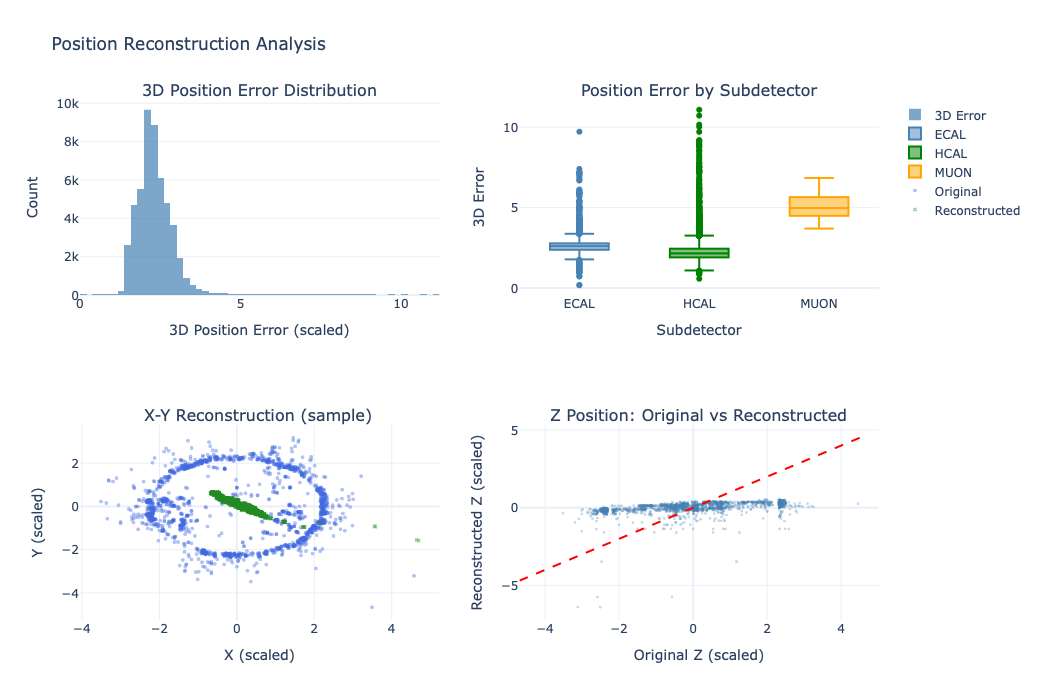

In [23]:
def plot_position_reconstruction(x_orig, x_reco, subdetector):
    """analyze spatial position reconstruction quality."""
    ### compute 3d distance error
    pos_error = np.sqrt(
        (x_orig[:, 0] - x_reco[:, 0])**2 +
        (x_orig[:, 1] - x_reco[:, 1])**2 +
        (x_orig[:, 2] - x_reco[:, 2])**2
    )
    
    fig = make_subplots(
        rows=2, cols=2,
        subplot_titles=[
            "3D Position Error Distribution",
            "Position Error by Subdetector",
            "X-Y Reconstruction (sample)",
            "Z Position: Original vs Reconstructed"
        ],
        specs=[
            [{"type": "histogram"}, {"type": "box"}],
            [{"type": "scatter"}, {"type": "scatter"}]
        ]
    )
    
    ### 1. overall 3d position error histogram
    fig.add_trace(
        go.Histogram(
            x=pos_error,
            nbinsx=100,
            marker_color='steelblue',
            opacity=0.7,
            name='3D Error'
        ),
        row=1, col=1
    )
    
    ### 2. box plot by subdetector
    for sd_code, sd_name in SUBDETECTOR_LABELS.items():
        mask = subdetector == sd_code
        if mask.sum() == 0:
            continue
        
        fig.add_trace(
            go.Box(
                y=pos_error[mask],
                name=sd_name,
                marker_color=SUBDETECTOR_COLORS[sd_code],
                boxpoints='outliers'
            ),
            row=1, col=2
        )
    
    ### 3. x-y scatter (sample)
    n_plot = min(2000, len(x_orig))
    idx = np.random.choice(len(x_orig), n_plot, replace=False)
    
    fig.add_trace(
        go.Scatter(
            x=x_orig[idx, 0], y=x_orig[idx, 1],
            mode='markers',
            marker=dict(size=4, color='royalblue', opacity=0.4),
            name='Original'
        ),
        row=2, col=1
    )
    
    fig.add_trace(
        go.Scatter(
            x=x_reco[idx, 0], y=x_reco[idx, 1],
            mode='markers',
            marker=dict(size=4, color='forestgreen', symbol='x', opacity=0.4),
            name='Reconstructed'
        ),
        row=2, col=1
    )
    
    ### 4. z position comparison
    fig.add_trace(
        go.Scatter(
            x=x_orig[idx, 2], y=x_reco[idx, 2],
            mode='markers',
            marker=dict(size=3, color='steelblue', opacity=0.3),
            showlegend=False
        ),
        row=2, col=2
    )
    
    ### diagonal reference
    z_range = [x_orig[:, 2].min(), x_orig[:, 2].max()]
    fig.add_trace(
        go.Scatter(x=z_range, y=z_range, mode='lines',
                   line=dict(color='red', dash='dash'), showlegend=False),
        row=2, col=2
    )
    
    ### labels
    fig.update_xaxes(title_text="3D Position Error (scaled)", row=1, col=1)
    fig.update_yaxes(title_text="Count", row=1, col=1)
    fig.update_xaxes(title_text="Subdetector", row=1, col=2)
    fig.update_yaxes(title_text="3D Error", row=1, col=2)
    fig.update_xaxes(title_text="X (scaled)", row=2, col=1)
    fig.update_yaxes(title_text="Y (scaled)", row=2, col=1)
    fig.update_xaxes(title_text="Original Z (scaled)", row=2, col=2)
    fig.update_yaxes(title_text="Reconstructed Z (scaled)", row=2, col=2)
    
    fig.update_layout(
        title="Position Reconstruction Analysis",
        height=700,
        width=1000,
        template="plotly_white"
    )
    
    fig.show()
    fig.write_html(OUTPUT_DIR / "position_reconstruction.html")

plot_position_reconstruction(x_orig, x_reco, subdetector)

---
# 5. 3D Event Visualization

Visualize original vs reconstructed calorimeter hits in 3D.

In [24]:
def plot_3d_event_comparison(results, event_idx=0, batch_size=BATCH_SIZE):
    """
    create interactive 3d visualization comparing original and reconstructed hits
    for a single event.
    """
    ### get a single event
    batch_idx = event_idx // batch_size
    within_batch_idx = event_idx % batch_size
    
    if batch_idx >= len(results["x_original"]):
        print(f"Event index {event_idx} out of range")
        return
    
    x_orig = results["x_original"][batch_idx][within_batch_idx]
    x_reco = results["x_reco"][batch_idx][within_batch_idx]
    mask = results["masks"][batch_idx][within_batch_idx]
    
    ### filter to valid hits
    valid = mask == 1
    x_orig = x_orig[valid]
    x_reco = x_reco[valid]
    
    if len(x_orig) == 0:
        print(f"No valid hits in event {event_idx}")
        return
    
    fig = make_subplots(
        rows=1, cols=2,
        subplot_titles=["Original Hits", "Reconstructed Hits"],
        specs=[[{"type": "scatter3d"}, {"type": "scatter3d"}]]
    )
    
    ### scale marker size by energy
    sizes_orig = np.clip(3 + 3 * np.log1p(np.abs(x_orig[:, 3])), 2, 15)
    sizes_reco = np.clip(3 + 3 * np.log1p(np.abs(x_reco[:, 3])), 2, 15)
    
    ### original hits
    fig.add_trace(
        go.Scatter3d(
            x=x_orig[:, 0], y=x_orig[:, 1], z=x_orig[:, 2],
            mode='markers',
            marker=dict(
                size=sizes_orig,
                color=x_orig[:, 3],
                colorscale='Viridis',
                opacity=0.7,
                colorbar=dict(title="Energy", x=0.45)
            ),
            name='Original',
            hovertemplate="x: %{x:.3f}<br>y: %{y:.3f}<br>z: %{z:.3f}<br>E: %{marker.color:.4f}"
        ),
        row=1, col=1
    )
    
    ### reconstructed hits
    fig.add_trace(
        go.Scatter3d(
            x=x_reco[:, 0], y=x_reco[:, 1], z=x_reco[:, 2],
            mode='markers',
            marker=dict(
                size=sizes_reco,
                color=x_reco[:, 3],
                colorscale='Viridis',
                opacity=0.7,
                colorbar=dict(title="Energy", x=1.0)
            ),
            name='Reconstructed',
            hovertemplate="x: %{x:.3f}<br>y: %{y:.3f}<br>z: %{z:.3f}<br>E: %{marker.color:.4f}"
        ),
        row=1, col=2
    )
    
    ### compute event-level mse
    event_mse = np.mean((x_orig - x_reco) ** 2)
    
    camera = dict(eye=dict(x=1.5, y=1.5, z=1.0))
    
    fig.update_layout(
        title=f"Event {event_idx}: Original vs Reconstructed ({len(x_orig)} hits, MSE={event_mse:.6f})",
        scene=dict(
            xaxis_title="X",
            yaxis_title="Y",
            zaxis_title="Z",
            camera=camera,
            aspectmode='data'
        ),
        scene2=dict(
            xaxis_title="X",
            yaxis_title="Y",
            zaxis_title="Z",
            camera=camera,
            aspectmode='data'
        ),
        height=600,
        width=1200,
        showlegend=False
    )
    
    fig.show()
    fig.write_html(OUTPUT_DIR / f"3d_event_{event_idx}.html")

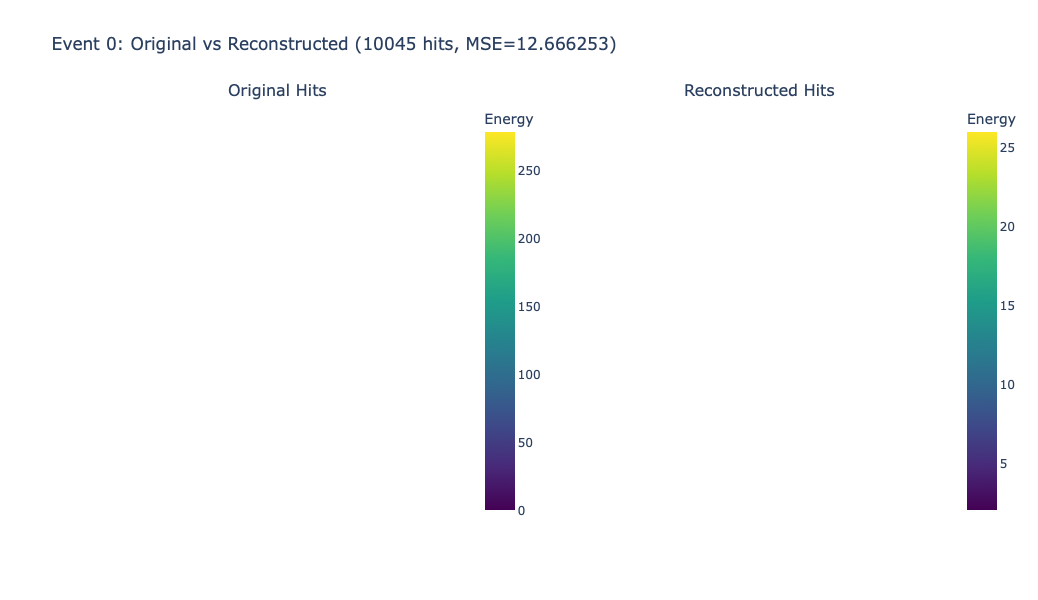

In [29]:
### visualize a few events
for event_idx in [0]:#, 5, 10]:
    plot_3d_event_comparison(results, event_idx)

---
# Summary

Comprehensive evaluation results for the VQ-VAE model.

In [26]:
def generate_summary_report(metrics, codebook_stats, subdet_metrics, checkpoint_path, num_codes):
    """generate a comprehensive summary of evaluation results."""
    
    report = []
    report.append("=" * 70)
    report.append("VQ-VAE EVALUATION SUMMARY REPORT")
    report.append("=" * 70)
    report.append(f"\nCheckpoint: {checkpoint_path.name}")
    report.append(f"Device: {DEVICE}")
    
    report.append("\n" + "-" * 50)
    report.append("RECONSTRUCTION QUALITY")
    report.append("-" * 50)
    report.append(f"Overall MSE: {np.mean(metrics['overall_mse']):.6f} +/- {np.std(metrics['overall_mse']):.6f}")
    report.append("\nPer-Feature MSE:")
    for i, name in enumerate(FEATURE_NAMES):
        report.append(f"  {name}: {np.mean(metrics['per_feature_mse'][i]):.6f}")
    
    report.append("\n" + "-" * 50)
    report.append("CODEBOOK UTILIZATION")
    report.append("-" * 50)
    report.append(f"Total codes: {num_codes}")
    report.append(f"Used codes: {codebook_stats['used_codes']} ({codebook_stats['usage_percentage']:.1f}%)")
    report.append(f"Dead codes: {codebook_stats['dead_codes']}")
    report.append(f"Normalized entropy: {codebook_stats['normalized_entropy']:.3f}")
    
    report.append("\n" + "-" * 50)
    report.append("PER-SUBDETECTOR METRICS")
    report.append("-" * 50)
    for sd_name, m in subdet_metrics.items():
        report.append(f"\n{sd_name}:")
        report.append(f"  Hits: {m['n_hits']:,}")
        report.append(f"  Overall MSE: {m['overall_mse']:.6f}")
    
    report.append("\n" + "=" * 70)
    
    report_text = "\n".join(report)
    print(report_text)
    
    ### save to file
    with open(OUTPUT_DIR / "evaluation_summary.txt", "w") as f:
        f.write(report_text)
    
    return report_text

summary = generate_summary_report(metrics, codebook_stats, subdet_metrics, CHECKPOINT_FILE, num_codes)

VQ-VAE EVALUATION SUMMARY REPORT

Checkpoint: embedder_deft-mountain-19_val_loss_epoch=47.ckpt
Device: cuda

--------------------------------------------------
RECONSTRUCTION QUALITY
--------------------------------------------------
Overall MSE: 11.370389 +/- 0.000000

Per-Feature MSE:
  x (scaled): 1.864237
  y (scaled): 1.773347
  z (scaled): 2.061296
  energy (scaled): 39.782677

--------------------------------------------------
CODEBOOK UTILIZATION
--------------------------------------------------
Total codes: 512
Used codes: 463 (90.4%)
Dead codes: 49
Normalized entropy: 0.849

--------------------------------------------------
PER-SUBDETECTOR METRICS
--------------------------------------------------

ECAL:
  Hits: 10,250
  Overall MSE: 8.124291

HCAL:
  Hits: 39,821
  Overall MSE: 12.209160

MUON:
  Hits: 40
  Overall MSE: 8.165545

